# 04 - Advanced semantic experiments

This notebook is intentionally not the primary submission pipeline. It is an
advanced robustness study: transformer embeddings, graph/density methods, and a
UMAP visualization are compared against the assignment-compatible TF-IDF + LSA +
KMeans solution.

Decision rule: the final `clusters.csv` should change only if the semantic
models are clearly better on internal metrics, stability, interpretability, and
assignment compatibility.


## Run 1 - Analysis / rationale

Load the submitted data and reuse the final anomaly split. This keeps the
semantic topic comparison focused on normal articles, just like the TF-IDF-LSA
topic model. The anomaly task is already handled with structural features, which
are more appropriate for unsafe/corrupted files.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "articles.csv").exists() and (ROOT.parent / "articles.csv").exists():
    ROOT = ROOT.parent
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

articles = pd.read_csv(ROOT / "articles.csv")
clusters = pd.read_csv(ROOT / "clusters.csv")
anomalies = pd.read_csv(ROOT / "anomalies.csv")

assert clusters["doc_id"].tolist() == articles["doc_id"].tolist()
assert anomalies.shape[0] == 50

normal_mask = ~articles["doc_id"].isin(anomalies["doc_id"])
normal_docs = articles.loc[normal_mask].reset_index(drop=True)
final_normal_labels = clusters.loc[normal_mask, "label"].to_numpy()

print("all documents:", len(articles))
print("normal documents used for semantic clustering:", len(normal_docs))
print("excluded structural anomalies:", len(articles) - len(normal_docs))


all documents: 2164
normal documents used for semantic clustering: 2114
excluded structural anomalies: 50


## Run 2 - Analysis / rationale

Use Sentence-BERT (`all-MiniLM-L6-v2`) to encode each document into a dense
semantic vector. This is more advanced than TF-IDF because it can group documents
by semantic similarity even when exact vocabulary differs.

Risk: embeddings are less transparent than TF-IDF. Therefore this is evaluated
as an alternative, not blindly adopted.


In [2]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedding_cache = OUTPUT_DIR / "sbert_all_minilm_l6_v2_clean_normal_embeddings.npy"
docid_cache = OUTPUT_DIR / "sbert_all_minilm_l6_v2_clean_normal_docids.csv"

def normalize_text_for_embedding(text: str) -> str:
    text = str(text)
    matches = list(re.finditer(r"\s--\s", text))
    if matches:
        last = matches[-1]
        if last.start() > len(text) * 0.45 or len(text) - last.start() < 900:
            text = text[: last.start()]
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+", " ", text)
    text = re.sub(r"\b[A-Z0-9]{5,}(?:-[A-Z0-9]{2,})+\b", " ", text)
    text = re.sub(r"[_=]{2,}|-{3,}", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

embedding_texts = normal_docs["text"].map(normalize_text_for_embedding).tolist()

if embedding_cache.exists() and docid_cache.exists():
    cached_ids = pd.read_csv(docid_cache)["doc_id"].tolist()
    if cached_ids == normal_docs["doc_id"].tolist():
        embeddings = np.load(embedding_cache)
    else:
        embeddings = None
else:
    embeddings = None

if embeddings is None:
    model = SentenceTransformer(MODEL_NAME)
    embeddings = model.encode(
        embedding_texts,
        batch_size=64,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    np.save(embedding_cache, embeddings)
    normal_docs[["doc_id"]].to_csv(docid_cache, index=False)

print("embedding model:", MODEL_NAME)
print("embedding matrix:", embeddings.shape, embeddings.dtype)
print("mean vector norm:", float(np.mean(np.linalg.norm(embeddings, axis=1))))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

embedding model: sentence-transformers/all-MiniLM-L6-v2
embedding matrix: (2114, 384) float32
mean vector norm: 1.0


## Run 3 - Analysis / rationale

Run KMeans on SBERT embeddings for k=5..9. This mirrors the TF-IDF-LSA
comparison. Cosine silhouette remains the main internal score because embeddings
are normalized and semantic direction matters more than vector length.


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score

def cluster_sizes(labels):
    values, counts = np.unique(labels, return_counts=True)
    return tuple((int(v), int(c)) for v, c in zip(values, counts))

kmeans_rows = []
kmeans_labels = {}
for k in range(5, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=500)
    labels = model.fit_predict(embeddings)
    kmeans_labels[k] = labels
    kmeans_rows.append(
        {
            "method": "SBERT_KMeans",
            "k": k,
            "silhouette_cosine": silhouette_score(embeddings, labels, metric="cosine"),
            "ari_vs_final_tfidf_labels": adjusted_rand_score(final_normal_labels, labels),
            "cluster_sizes": cluster_sizes(labels),
        }
    )

sbert_kmeans_eval = pd.DataFrame(kmeans_rows)
sbert_kmeans_eval.to_csv(OUTPUT_DIR / "advanced_sbert_kmeans_eval.csv", index=False)
display(sbert_kmeans_eval)


,method,k,silhouette_cosine,ari_vs_final_tfidf_labels,cluster_sizes
0,SBERT_KMeans,5,0.119008,0.553373,"((0, 400), (1, 397), (2, 425), (3, 375), (4, 5..."
1,SBERT_KMeans,6,0.113512,0.543974,"((0, 332), (1, 414), (2, 199), (3, 369), (4, 4..."
2,SBERT_KMeans,7,0.109443,0.510025,"((0, 293), (1, 325), (2, 409), (3, 393), (4, 1..."
3,SBERT_KMeans,8,0.106587,0.507116,"((0, 391), (1, 278), (2, 144), (3, 326), (4, 3..."
4,SBERT_KMeans,9,0.102386,0.481048,"((0, 391), (1, 154), (2, 236), (3, 208), (4, 3..."


## Run 3b - Analysis / rationale

Transformer clusters need post-hoc interpretation. Unlike TF-IDF KMeans, SBERT
KMeans does not directly expose word-weight centroids. To keep the comparison
fair and reportable, I compute TF-IDF top terms and representative examples for
the best SBERT KMeans setting and for k=6.


In [4]:
custom_stop = list(
    ENGLISH_STOP_WORDS.union(
        {
            "edu",
            "com",
            "article",
            "writes",
            "posting",
            "host",
            "nntp",
            "university",
            "subject",
            "lines",
            "organization",
        }
    )
)

def clean_text_for_terms(text: str) -> str:
    text = str(text)
    matches = list(re.finditer(r"\s--\s", text))
    if matches:
        last = matches[-1]
        if last.start() > len(text) * 0.45 or len(text) - last.start() < 900:
            text = text[: last.start()]
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+", " ", text)
    text = re.sub(r"\b[A-Z0-9]{5,}(?:-[A-Z0-9]{2,})+\b", " ", text)
    text = re.sub(r"[_=]{2,}|-{3,}", " ", text)
    return text

term_vectorizer = TfidfVectorizer(
    stop_words=custom_stop,
    min_df=4,
    max_df=0.55,
    sublinear_tf=True,
    norm="l2",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
term_matrix = term_vectorizer.fit_transform(normal_docs["text"].map(clean_text_for_terms))
term_names = np.array(term_vectorizer.get_feature_names_out())

def top_terms_for_labels(labels, label_name, top_n=16):
    rows = []
    for cluster_id in sorted(np.unique(labels)):
        idx = np.where(labels == cluster_id)[0]
        mean_weights = np.asarray(term_matrix[idx].mean(axis=0)).ravel()
        top_idx = mean_weights.argsort()[-top_n:][::-1]
        examples = normal_docs.iloc[idx[:5]]["doc_id"].tolist()
        rows.append(
            {
                "label_set": label_name,
                "cluster": int(cluster_id),
                "size": int(len(idx)),
                "top_terms": ", ".join(term_names[top_idx]),
                "example_doc_ids": examples,
            }
        )
    return pd.DataFrame(rows)

best_sbert_k = int(sbert_kmeans_eval.sort_values("silhouette_cosine", ascending=False).iloc[0]["k"])
sbert_top_terms = pd.concat(
    [
        top_terms_for_labels(kmeans_labels[best_sbert_k], f"SBERT_KMeans_k{best_sbert_k}"),
        top_terms_for_labels(kmeans_labels[6], "SBERT_KMeans_k6"),
    ],
    ignore_index=True,
)
sbert_top_terms.to_csv(OUTPUT_DIR / "advanced_sbert_kmeans_top_terms.csv", index=False)
display(sbert_top_terms)


,label_set,cluster,size,top_terms,example_doc_ids
0,SBERT_KMeans_k5,0,400,"car, cars, like, just, engine, don, good, deal...","[DOC_00006, DOC_00013, DOC_00014, DOC_00015, D..."
1,SBERT_KMeans_k5,1,397,"game, team, hockey, play, games, players, seas...","[DOC_00011, DOC_00024, DOC_00040, DOC_00051, D..."
2,SBERT_KMeans_k5,2,425,"don, know, people, msg, doctor, disease, medic...","[DOC_00004, DOC_00008, DOC_00010, DOC_00023, D..."
3,SBERT_KMeans_k5,3,375,"graphics, thanks, files, program, image, file,...","[DOC_00005, DOC_00017, DOC_00020, DOC_00026, D..."
4,SBERT_KMeans_k5,4,517,"space, like, just, think, orbit, don, know, ea...","[DOC_00001, DOC_00002, DOC_00003, DOC_00007, D..."
5,SBERT_KMeans_k6,0,332,"graphics, thanks, files, program, windows, fil...","[DOC_00005, DOC_00017, DOC_00020, DOC_00033, D..."
6,SBERT_KMeans_k6,1,414,"space, just, like, don, think, know, orbit, da...","[DOC_00001, DOC_00003, DOC_00007, DOC_00009, D..."
7,SBERT_KMeans_k6,2,199,"space, moon, people, nasa, lunar, just, like, ...","[DOC_00002, DOC_00039, DOC_00044, DOC_00046, D..."
8,SBERT_KMeans_k6,3,369,"car, cars, like, just, engine, dealer, good, d...","[DOC_00006, DOC_00013, DOC_00014, DOC_00015, D..."
9,SBERT_KMeans_k6,4,406,"don, know, msg, doctor, disease, people, medic...","[DOC_00004, DOC_00008, DOC_00010, DOC_00023, D..."


## Run 4 - Analysis / rationale

Run agglomerative clustering on the same SBERT embeddings. Average linkage with
cosine distance is a natural semantic-clustering comparison because it links
clusters by average angular distance rather than centroid variance.


In [5]:
agg_rows = []
agg_labels = {}
for k in range(5, 10):
    agg = AgglomerativeClustering(n_clusters=k, linkage="average", metric="cosine")
    labels = agg.fit_predict(embeddings)
    agg_labels[k] = labels
    agg_rows.append(
        {
            "method": "SBERT_AgglomerativeAverageCosine",
            "k": k,
            "silhouette_cosine": silhouette_score(embeddings, labels, metric="cosine"),
            "ari_vs_final_tfidf_labels": adjusted_rand_score(final_normal_labels, labels),
            "cluster_sizes": cluster_sizes(labels),
        }
    )

sbert_agg_eval = pd.DataFrame(agg_rows)
sbert_agg_eval.to_csv(OUTPUT_DIR / "advanced_sbert_agglomerative_eval.csv", index=False)
display(sbert_agg_eval)


,method,k,silhouette_cosine,ari_vs_final_tfidf_labels,cluster_sizes
0,SBERT_AgglomerativeAverageCosine,5,0.089675,0.418088,"((0, 911), (1, 381), (2, 434), (3, 1), (4, 387))"
1,SBERT_AgglomerativeAverageCosine,6,0.081533,0.418250,"((0, 900), (1, 381), (2, 11), (3, 1), (4, 387)..."
2,SBERT_AgglomerativeAverageCosine,7,0.091887,0.512005,"((0, 445), (1, 381), (2, 455), (3, 1), (4, 387..."
3,SBERT_AgglomerativeAverageCosine,8,0.088069,0.512311,"((0, 381), (1, 425), (2, 455), (3, 20), (4, 38..."
4,SBERT_AgglomerativeAverageCosine,9,0.082124,0.512753,"((0, 379), (1, 425), (2, 455), (3, 20), (4, 38..."


## Run 5 - Analysis / rationale

Run HDBSCAN as a density-based advanced alternative. HDBSCAN can identify noise
and variable-density groups, which KMeans cannot. However, it does not naturally
respect the assignment's maximum-10-cluster output format, so it is mainly a
research-style comparison.


In [6]:
import hdbscan

hdbscan_rows = []
hdbscan_labels_by_setting = {}
for min_cluster_size in [25, 40, 60]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=10,
        metric="euclidean",
        prediction_data=False,
    )
    labels = clusterer.fit_predict(embeddings)
    hdbscan_labels_by_setting[min_cluster_size] = labels
    non_noise = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    silhouette = (
        silhouette_score(embeddings[non_noise], labels[non_noise], metric="cosine")
        if n_clusters >= 2 and non_noise.sum() > 1
        else np.nan
    )
    hdbscan_rows.append(
        {
            "method": "SBERT_HDBSCAN",
            "min_cluster_size": min_cluster_size,
            "n_clusters_excluding_noise": n_clusters,
            "noise_count": noise_count,
            "silhouette_cosine_non_noise": silhouette,
            "ari_vs_final_tfidf_labels_all_points": adjusted_rand_score(final_normal_labels, labels),
            "cluster_sizes": cluster_sizes(labels),
        }
    )

hdbscan_eval = pd.DataFrame(hdbscan_rows)
hdbscan_eval.to_csv(OUTPUT_DIR / "advanced_hdbscan_eval.csv", index=False)
display(hdbscan_eval)


,method,min_cluster_size,n_clusters_excluding_noise,noise_count,silhouette_cosine_non_noise,ari_vs_final_tfidf_labels_all_points,cluster_sizes
0,SBERT_HDBSCAN,25,5,1355,0.238768,0.178883,"((-1, 1355), (0, 364), (1, 159), (2, 104), (3,..."
1,SBERT_HDBSCAN,40,5,1355,0.238768,0.178883,"((-1, 1355), (0, 364), (1, 159), (2, 104), (3,..."
2,SBERT_HDBSCAN,60,4,1303,0.224221,0.186930,"((-1, 1303), (0, 364), (1, 159), (2, 184), (3,..."


## Run 6 - Analysis / rationale

Run BERTopic as an optional modern topic-modeling pipeline. BERTopic combines
embeddings, UMAP, HDBSCAN, and c-TF-IDF topic words. It is useful as a research
reference, but if it produces too many topics or a large noise class it is less
compatible with this assignment's fixed cluster CSV requirement.


In [7]:
bertopic_status = []
try:
    import umap
    from bertopic import BERTopic

    topic_umap = umap.UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    )
    topic_hdbscan = hdbscan.HDBSCAN(
        min_cluster_size=40,
        min_samples=10,
        metric="euclidean",
        prediction_data=False,
    )
    topic_model = BERTopic(
        embedding_model=None,
        umap_model=topic_umap,
        hdbscan_model=topic_hdbscan,
        vectorizer_model=CountVectorizer(stop_words=custom_stop, min_df=1),
        calculate_probabilities=False,
        verbose=False,
        top_n_words=10,
    )
    topics, _ = topic_model.fit_transform(embedding_texts, embeddings)
    topic_info = topic_model.get_topic_info()
    topic_info.to_csv(OUTPUT_DIR / "advanced_bertopic_topic_info.csv", index=False)

    topic_rows = []
    for topic_id in topic_info["Topic"].head(12):
        words = topic_model.get_topic(int(topic_id))
        topic_rows.append(
            {
                "topic": int(topic_id),
                "top_words": ", ".join([w for w, _ in words]) if words else "",
            }
        )
    bertopic_topics = pd.DataFrame(topic_rows)
    bertopic_topics.to_csv(OUTPUT_DIR / "advanced_bertopic_top_words.csv", index=False)

    bertopic_status.append(
        {
            "status": "completed",
            "topics_excluding_noise": int((topic_info["Topic"] != -1).sum()),
            "noise_documents": int(topic_info.loc[topic_info["Topic"] == -1, "Count"].sum()) if (topic_info["Topic"] == -1).any() else 0,
        }
    )
    display(topic_info.head(12))
    display(bertopic_topics)
except Exception as exc:
    bertopic_status.append({"status": "skipped_or_failed", "error": repr(exc)})

bertopic_status_df = pd.DataFrame(bertopic_status)
bertopic_status_df.to_csv(OUTPUT_DIR / "advanced_bertopic_status.csv", index=False)
display(bertopic_status_df)


,Topic,Count,Name,Representation,Representative_Docs
0,0,1315,0_like_just_dont_car,"[like, just, dont, car, space, know, people, t...",[... ... Some other owners on the mailing list...
1,1,416,1_team_550_game_25,"[team, 550, game, 25, hockey, players, season,...","[Well, I'm back from Tokyo, so here are the st..."
2,2,383,2_graphics_image_thanks_files,"[graphics, image, thanks, files, program, use,...","[Sorry I missed you Raymond, I was just out in..."


,topic,top_words
0,0,"like, just, dont, car, space, know, people, th..."
1,1,"team, 550, game, 25, hockey, players, season, ..."
2,2,"graphics, image, thanks, files, program, use, ..."


,status,topics_excluding_noise,noise_documents
0,completed,3,0


## Run 7 - Analysis / rationale

Create a UMAP 2D visualization of SBERT embeddings. This is not used as a final
metric. It is a qualitative diagnostic showing whether semantic clusters are
separated or overlapping.


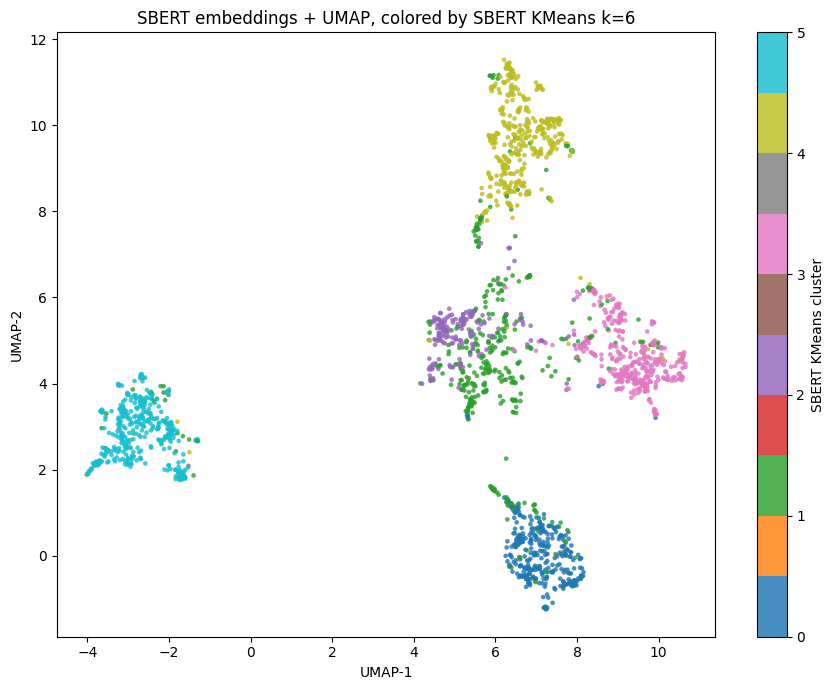

saved: /Users/alperendavran/Desktop/data mining hw3/outputs/advanced_umap_sbert_kmeans6.png


In [8]:
import matplotlib.pyplot as plt
import umap

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.05,
    metric="cosine",
    random_state=42,
)
coords = umap_2d.fit_transform(embeddings)

selected_k = 6
selected_sbert_labels = kmeans_labels[selected_k]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=selected_sbert_labels,
    cmap="tab10",
    s=11,
    alpha=0.82,
    linewidths=0,
)
plt.title("SBERT embeddings + UMAP, colored by SBERT KMeans k=6")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label="SBERT KMeans cluster")
plt.tight_layout()
umap_path = OUTPUT_DIR / "advanced_umap_sbert_kmeans6.png"
plt.savefig(umap_path, dpi=180)
plt.show()

umap_df = pd.DataFrame(
    {
        "doc_id": normal_docs["doc_id"],
        "umap_x": coords[:, 0],
        "umap_y": coords[:, 1],
        "sbert_kmeans6": selected_sbert_labels,
        "final_tfidf_label": final_normal_labels,
    }
)
umap_df.to_csv(OUTPUT_DIR / "advanced_umap_coordinates.csv", index=False)
print("saved:", umap_path)


## Run 8 - Analysis / rationale

Summarize whether the advanced semantic methods should replace the current final
CSV. The decision is intentionally conservative: an advanced model should not
replace a simpler model unless it is clearly better and still assignment-
compatible.


In [9]:
baseline = pd.read_csv(OUTPUT_DIR / "clustering_model_comparison.csv")
baseline_kmeans6 = baseline[(baseline["algorithm"] == "KMeans") & (baseline["k"] == 6)].iloc[0]
best_sbert_kmeans = sbert_kmeans_eval.sort_values("silhouette_cosine", ascending=False).iloc[0]
best_sbert_agg = sbert_agg_eval.sort_values("silhouette_cosine", ascending=False).iloc[0]

decision_rows = [
    {
        "candidate": "Current final: TF-IDF + LSA + KMeans k=6",
        "silhouette_cosine": baseline_kmeans6["silhouette_cosine"],
        "assignment_compatible": True,
        "interpretability": "high: top TF-IDF terms and representative documents",
        "decision": "retain as final unless advanced method is clearly better",
    },
    {
        "candidate": f"Best SBERT KMeans k={int(best_sbert_kmeans['k'])}",
        "silhouette_cosine": best_sbert_kmeans["silhouette_cosine"],
        "assignment_compatible": True,
        "interpretability": "medium: semantic clusters require post-hoc terms",
        "decision": "advanced comparison only unless clearly superior",
    },
    {
        "candidate": f"Best SBERT Agglomerative k={int(best_sbert_agg['k'])}",
        "silhouette_cosine": best_sbert_agg["silhouette_cosine"],
        "assignment_compatible": True,
        "interpretability": "medium-low: no centroids",
        "decision": "advanced comparison only",
    },
]

decision_df = pd.DataFrame(decision_rows)
decision_df.to_csv(OUTPUT_DIR / "advanced_semantic_decision_table.csv", index=False)
display(decision_df)

summary = f"""Advanced semantic experiment summary
====================================

Baseline final model:
- TF-IDF + LSA + KMeans k=6
- cosine silhouette: {baseline_kmeans6['silhouette_cosine']:.6f}
- strengths: direct assignment fit, interpretable top terms, stable semantic categories

Best SBERT KMeans:
- k={int(best_sbert_kmeans['k'])}
- cosine silhouette: {best_sbert_kmeans['silhouette_cosine']:.6f}
- ARI vs final TF-IDF labels: {best_sbert_kmeans['ari_vs_final_tfidf_labels']:.6f}

Best SBERT Agglomerative:
- k={int(best_sbert_agg['k'])}
- cosine silhouette: {best_sbert_agg['silhouette_cosine']:.6f}
- ARI vs final TF-IDF labels: {best_sbert_agg['ari_vs_final_tfidf_labels']:.6f}

Decision:
Keep the submitted clusters.csv unchanged unless the report explicitly wants a
semantic-embedding alternative. The advanced models are valuable as a robustness
section, but the TF-IDF-LSA-KMeans solution remains more transparent and easier
to justify under the assignment rubric.
"""

(OUTPUT_DIR / "advanced_semantic_decision_summary.md").write_text(summary)
print(summary)


,candidate,silhouette_cosine,assignment_compatible,interpretability,decision
0,Current final: TF-IDF + LSA + KMeans k=6,0.118880,True,high: top TF-IDF terms and representative docu...,retain as final unless advanced method is clea...
1,Best SBERT KMeans k=5,0.119008,True,medium: semantic clusters require post-hoc terms,advanced comparison only unless clearly superior
2,Best SBERT Agglomerative k=7,0.091887,True,medium-low: no centroids,advanced comparison only


Advanced semantic experiment summary

Baseline final model:
- TF-IDF + LSA + KMeans k=6
- cosine silhouette: 0.118880
- strengths: direct assignment fit, interpretable top terms, stable semantic categories

Best SBERT KMeans:
- k=5
- cosine silhouette: 0.119008
- ARI vs final TF-IDF labels: 0.553373

Best SBERT Agglomerative:
- k=7
- cosine silhouette: 0.091887
- ARI vs final TF-IDF labels: 0.512005

Decision:
Keep the submitted clusters.csv unchanged unless the report explicitly wants a
semantic-embedding alternative. The advanced models are valuable as a robustness
section, but the TF-IDF-LSA-KMeans solution remains more transparent and easier
to justify under the assignment rubric.

